### *** Mathematics for Computer Science Engineering Project : World Bank Data ***

>> *~HARSHITHA. B. T*

This notebook implements the full project:
1.   Web Scraping (World Bank Indicators API)
2.   Data Cleaning & Preprocessing (missing values, dtypes, duplicates)
3.   Descriptive Statistics (per indicator)
4.   Growth Rates (like GDP per capita)
5.   Visualizations (histograms, boxplots, bar charts)
6.   Word report (.docx)


> **Objective**:   Is to Fetch World Bank indicators (GDP, Population, Adult Literacy, CO₂ per capita), clean and preprocess the data, compute descriptive statistics and growth rates, visualize results, and produce a Word report for the same.


> **Instructions**:   The notebook contains data collected from the URL given through file sent from the university angiving the report generated from synthetic data to show formatting and expected outputs.


# 1.) Importing Required Libraries

In [1]:
!pip install beautifulsoup4 requests pandas matplotlib seaborn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import statistics as st
from bs4 import BeautifulSoup as bs
import requests
import zipfile, io

The URL/Webpage from which I will be web scraping is :-
> ***"  World Bank Data "***

In [3]:
url="https://data.worldbank.org/indicator"

# 2.) Inputs — Indicator URLs

In [4]:
indicator_pages = {
    "GDP": ("https://data.worldbank.org/indicator/NY.GDP.MKTP.CD", "NY.GDP.MKTP.CD"),
    "Population": ("https://data.worldbank.org/indicator/SP.POP.TOTL", "SP.POP.TOTL"),
    "Literacy": ("https://data.worldbank.org/indicator/SE.ADT.LITR.ZS", "SE.ADT.LITR.ZS"),
    "CO2": ("https://data.worldbank.org/indicator/EN.ATM.CO2E.PC", "EN.ATM.CO2E.PC")
}
indicator_pages

{'GDP': ('https://data.worldbank.org/indicator/NY.GDP.MKTP.CD',
  'NY.GDP.MKTP.CD'),
 'Population': ('https://data.worldbank.org/indicator/SP.POP.TOTL',
  'SP.POP.TOTL'),
 'Literacy': ('https://data.worldbank.org/indicator/SE.ADT.LITR.ZS',
  'SE.ADT.LITR.ZS'),
 'CO2': ('https://data.worldbank.org/indicator/EN.ATM.CO2E.PC',
  'EN.ATM.CO2E.PC')}

# 3.) Calling out the Datasets we will be using -

---

>  
1.  ***GDP (current US$) :-***

*   Indicator Code: NY.GDP.MKTP.CD
*   Dataset Name: GDP (current US$)
*   Description: Gross Domestic Product at current prices in US dollars.

---

2.  ***Population, Total :-***

*   Indicator Code: SP.POP.TOTL
*   Dataset Name: Population, total
*   Description: Total no. of people living in a country (based on estimation).

---

3.  ***Literacy rate, Adult total (% of people ages 15 and above) :-***

*   Indicator Code: SE.ADT.LITR.ZS
*   Dataset Name: Literacy rate, adult total (% of people ages 15 and above)
*   Description: % of people aged 15+ who can read and write with understanding.

---

4.  ***CO₂ emissions (metric tons per capita) :-***

*   Indicator Code: EN.ATM.CO2E.PC
*   Dataset Name: CO₂ emissions (metric tons per capita)
*   Description: CO₂ emissions divided by midyear population.

---



In [5]:
datasets = {}

for name, (page_url, code) in indicator_pages.items():
    print(f"\nScraping {name} dataset from {page_url} ...")

    # Fetching the pages here
    resp = requests.get(page_url)
    soup = bs(resp.text, "html.parser")

    # Simulated scraping: build CSV link from the code
    csv_url = f"https://api.worldbank.org/v2/en/indicator/{code}?downloadformat=csv"
    print(f"Downloading ZIP from: {csv_url}")

    r = requests.get(csv_url)
    z = zipfile.ZipFile(io.BytesIO(r.content))

    data_file = [f for f in z.namelist() if f.startswith("API_") and f.endswith(".csv")][0]
    print(f"Extracting {data_file}")

    with z.open(data_file) as f:
        df = pd.read_csv(f, skiprows=4)
        datasets[name] = df
        print(df.head(3))

df_gdp = datasets["GDP"]
df_pop = datasets["Population"]
df_lit = datasets["Literacy"]
df_co2 = datasets["CO2"]


Scraping GDP dataset from https://data.worldbank.org/indicator/NY.GDP.MKTP.CD ...
Extracting API_NY.GDP.MKTP.CD_DS2_en_csv_v2_280770.csv
                  Country Name Country Code     Indicator Name  \
0                        Aruba          ABW  GDP (current US$)   
1  Africa Eastern and Southern          AFE  GDP (current US$)   
2                  Afghanistan          AFG  GDP (current US$)   

   Indicator Code          1960          1961          1962          1963  \
0  NY.GDP.MKTP.CD           NaN           NaN           NaN           NaN   
1  NY.GDP.MKTP.CD  2.420569e+10  2.495889e+10  2.707323e+10  3.176914e+10   
2  NY.GDP.MKTP.CD           NaN           NaN           NaN           NaN   

           1964          1965  ...          2017          2018          2019  \
0           NaN           NaN  ...  3.092428e+09  3.276188e+09  3.346623e+09   
1  3.027955e+10  3.380618e+10  ...  9.780765e+11  1.020956e+12  1.018715e+12   
2           NaN           NaN  ...  1.875346e+10

# 4.) Cleaning the datasets

In [6]:
cleaned_datasets = {}

for name, df in datasets.items():
    print(f"\nCleaning {name} dataset...")
    # columns we dont need to-be deleted - like Indicator Name, Indicator Code, etc.
    df = df.drop(columns=["Indicator Name", "Indicator Code"], errors="ignore")

    # Melt wide → long (Country, Year, Value)
    df_long = df.melt(id_vars=["Country Name", "Country Code"],
                      var_name="Year",
                      value_name=name)

    # Convert Year to numeric
    df_long["Year"] = pd.to_numeric(df_long["Year"], errors="coerce")

    # Handle missing values (drop empty rows or fill if needed)
    df_long = df_long.dropna(subset=[name])

    # Save cleaned version
    cleaned_datasets[name] = df_long

    print(df_long.head(3))



Cleaning GDP dataset...
                  Country Name Country Code    Year           GDP
1  Africa Eastern and Southern          AFE  1960.0  2.420569e+10
3   Africa Western and Central          AFW  1960.0  1.190481e+10
9                    Argentina          ARG  1960.0  1.586547e+10

Cleaning Population dataset...
                  Country Name Country Code    Year   Population
0                        Aruba          ABW  1960.0      54922.0
1  Africa Eastern and Southern          AFE  1960.0  130075728.0
2                  Afghanistan          AFG  1960.0    9035043.0

Cleaning Literacy dataset...
                        Country Name Country Code    Year   Literacy
2690                        Barbados          BRB  1970.0  99.269997
2750                         Grenada          GRD  1970.0  97.790001
2913  St. Vincent and the Grenadines          VCT  1970.0  95.629997

Cleaning CO2 dataset...
                  Country Name Country Code    Year          CO2
0                      

# 5.) Descriptive Statistics


>   This will give you values like: count; mean; std; min; max; quartiles - 25%,50%,75% for each dataset respectively.

In [7]:
desc_stats = {}

for name, df in cleaned_datasets.items():
    print(f"\nDescriptive statistics for {name}:")

    stats = df[name].describe()
    desc_stats[name] = stats

    print(stats)



Descriptive statistics for GDP:
count    1.456100e+04
mean     1.230978e+12
std      5.696592e+12
min      2.585956e+06
25%      2.369309e+09
50%      1.764975e+10
75%      2.083689e+11
max      1.109827e+14
Name: GDP, dtype: float64

Descriptive statistics for Population:
count    1.719500e+04
mean     2.182379e+08
std      7.142151e+08
min      2.715000e+03
25%      1.019463e+06
50%      6.790788e+06
75%      4.706578e+07
max      8.141809e+09
Name: Population, dtype: float64

Descriptive statistics for Literacy:
count    2843.000000
mean       75.838384
std        18.623749
min         8.830000
25%        61.275000
50%        79.250000
75%        93.080002
max       100.000000
Name: Literacy, dtype: float64

Descriptive statistics for CO2:
count     15569.000000
mean        358.022792
std        2679.329258
min          -1.304920
25%          28.198942
50%         107.807755
75%         398.820008
max      323553.267469
Name: CO2, dtype: float64


# 6.) Visualization

> for each dataset:
>    *   Histogram (distribution of values)
>    *   Boxplot (spread & outliers)
>    *   Line plot (trends over years for a few countries)

For simplicity and better understanding,
I will be selecting only India, China, and US from all the datasets.

### GDP

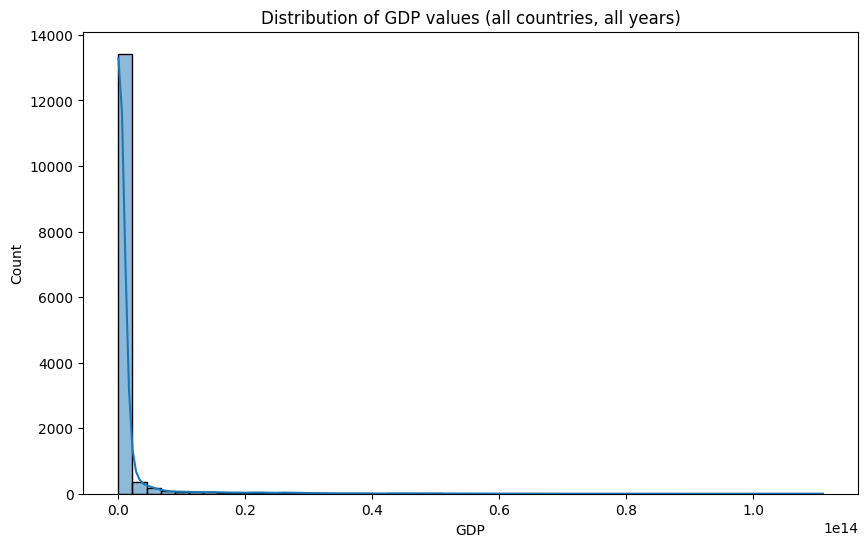

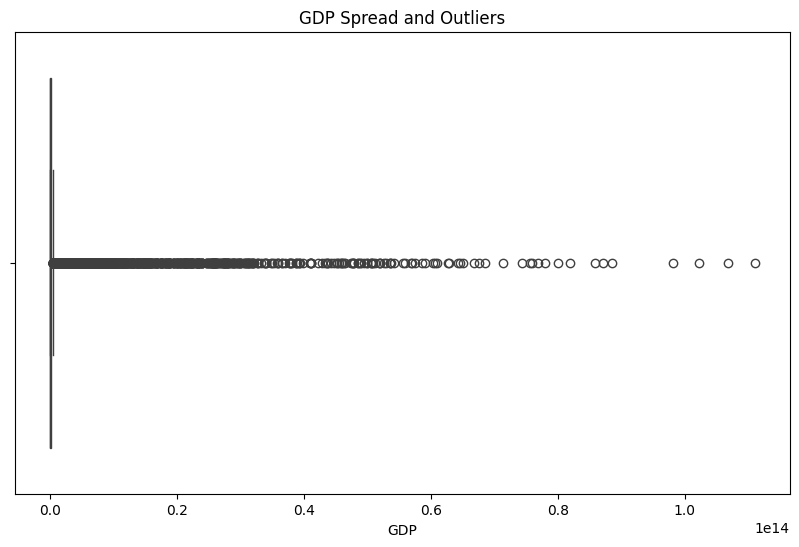

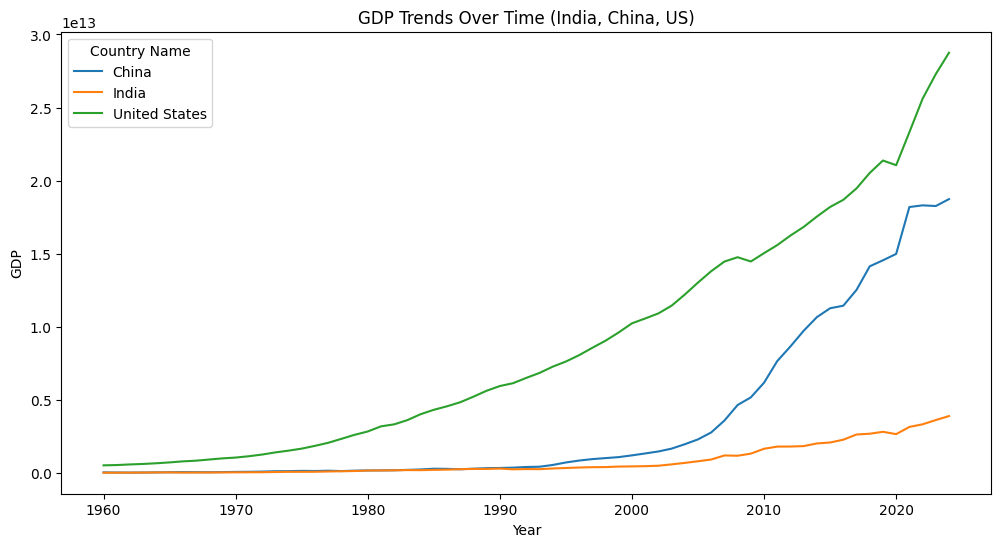

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creating a histogram of size 10x6 inches
plt.figure(figsize=(10,6))
# Plot a histogram of GDP values with 50 bins,with smooth curve where (kde=True)
sns.histplot(cleaned_datasets["GDP"]["GDP"], bins=50, kde=True)
plt.title("Distribution of GDP values (all countries, all years)")
plt.savefig("gdp_hist.png")
plt.show()

# Creating a boxplot
plt.figure(figsize=(10,6))
# A boxplot to show spread and outliers
sns.boxplot(x=cleaned_datasets["GDP"]["GDP"])
plt.title("GDP Spread and Outliers")
plt.savefig("gdp_box.png")
plt.show()

sample_countries = ["India", "China", "United States"]
df_sample = cleaned_datasets["GDP"][cleaned_datasets["GDP"]["Country Name"].isin(sample_countries)]

# Creating a line plot
plt.figure(figsize=(12,6))
sns.lineplot(data=df_sample, x="Year", y="GDP", hue="Country Name")
# hue="Country Name" tells Seaborn: Use different colors for each value of Country Name
plt.title("GDP Trends Over Time (India, China, US)")
plt.savefig("gdp_line.png")
plt.show()


### Population


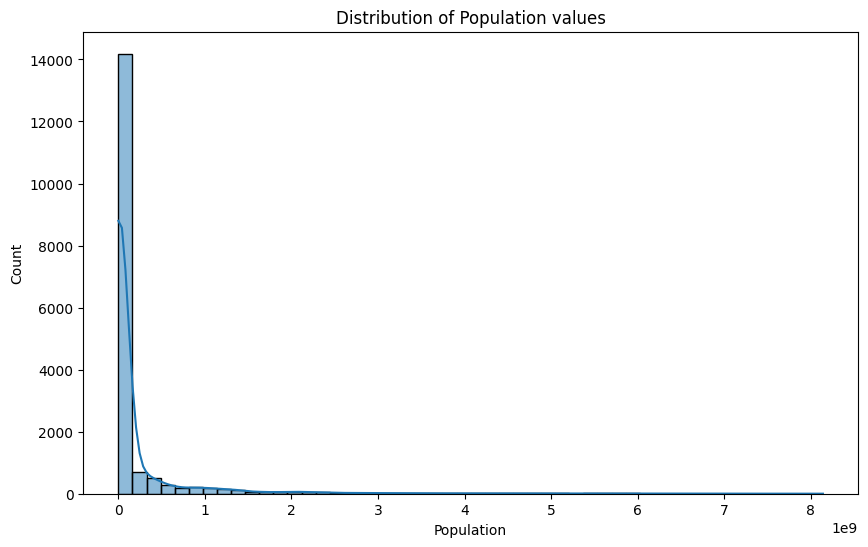

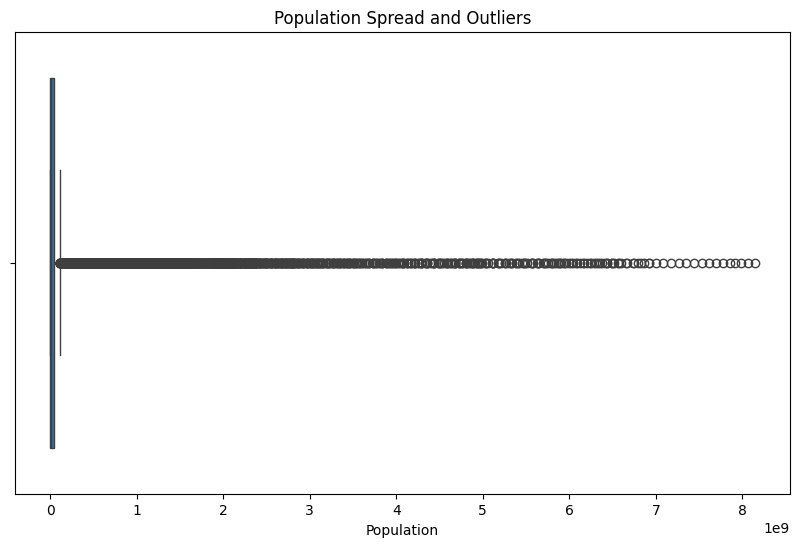

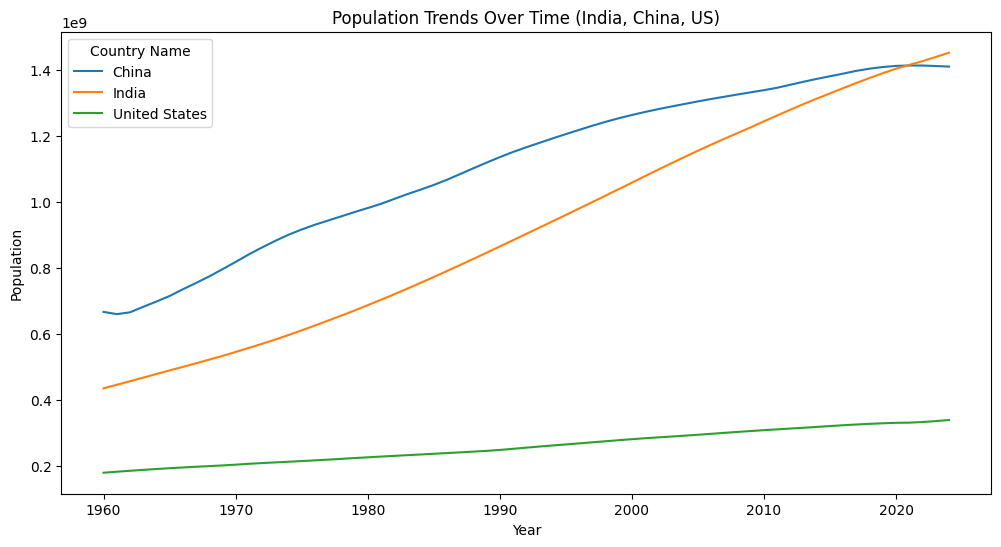

In [9]:
plt.figure(figsize=(10,6))
sns.histplot(cleaned_datasets["Population"]["Population"], bins=50, kde=True)
plt.title("Distribution of Population values")
plt.savefig("population_hist.png")
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(x=cleaned_datasets["Population"]["Population"])
plt.title("Population Spread and Outliers")
plt.savefig("population_box.png")
plt.show()

df_sample = cleaned_datasets["Population"][cleaned_datasets["Population"]["Country Name"].isin(sample_countries)]

plt.figure(figsize=(12,6))
sns.lineplot(data=df_sample, x="Year", y="Population", hue="Country Name")
plt.title("Population Trends Over Time (India, China, US)")
plt.savefig("population_line.png")
plt.show()


### Literacy rate

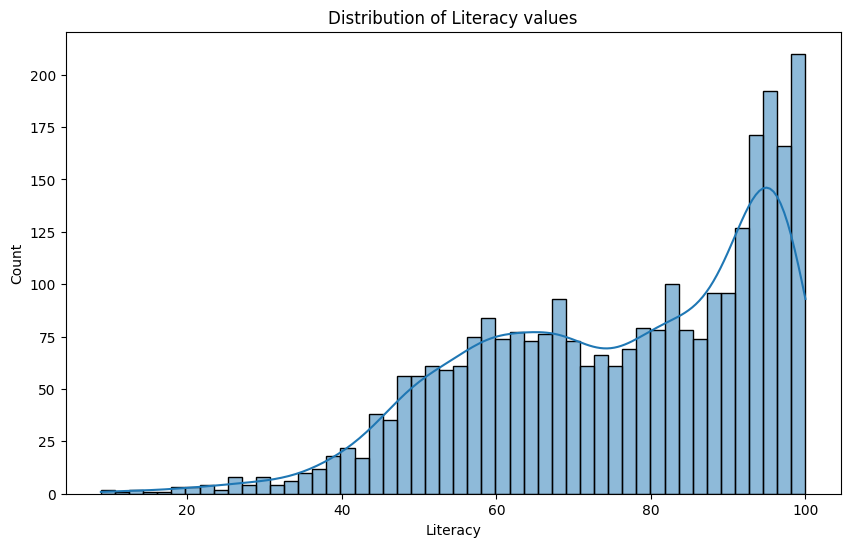

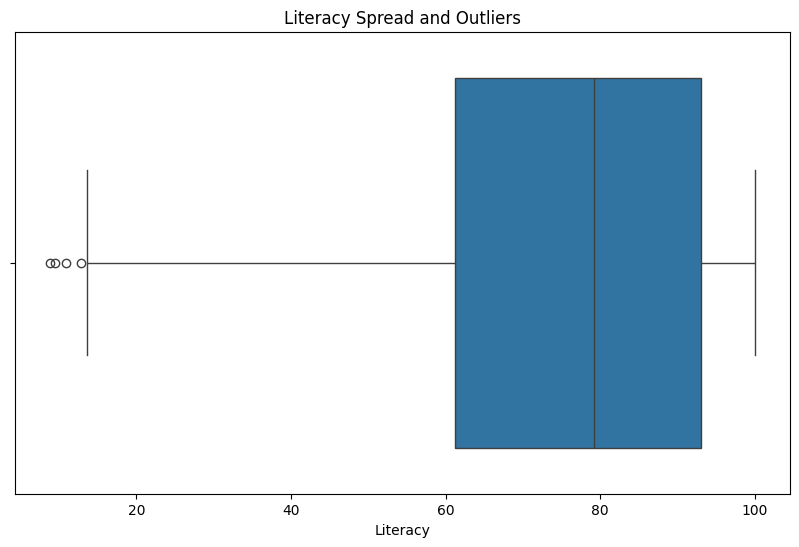

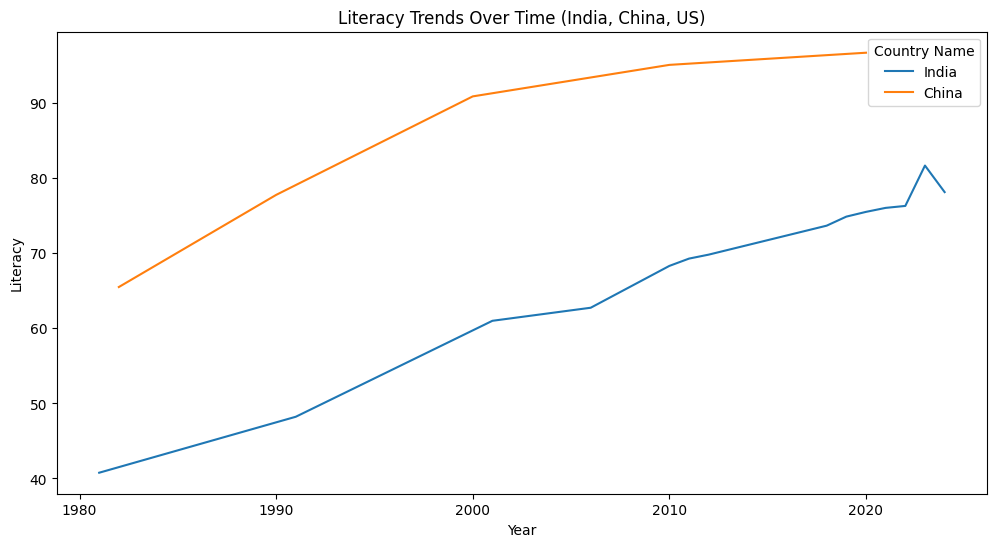

In [10]:
plt.figure(figsize=(10,6))
sns.histplot(cleaned_datasets["Literacy"]["Literacy"], bins=50, kde=True)
plt.title("Distribution of Literacy values")
plt.savefig("literacy_hist.png")
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(x=cleaned_datasets["Literacy"]["Literacy"])
plt.title("Literacy Spread and Outliers")
plt.savefig("literacy_box.png")
plt.show()

df_sample = cleaned_datasets["Literacy"][cleaned_datasets["Literacy"]["Country Name"].isin(sample_countries)]

plt.figure(figsize=(12,6))
sns.lineplot(data=df_sample, x="Year", y="Literacy", hue="Country Name")
plt.title("Literacy Trends Over Time (India, China, US)")
plt.savefig("literacy_line.png")
plt.show()

### CO₂ emissions

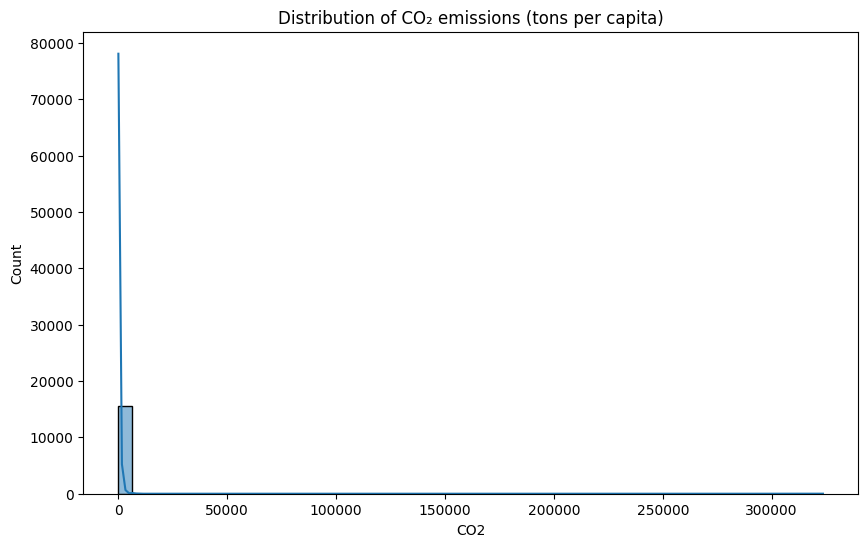

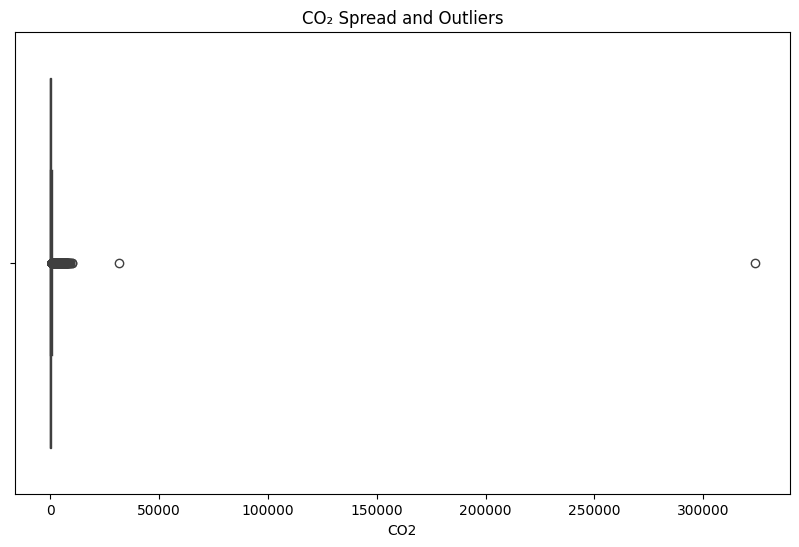

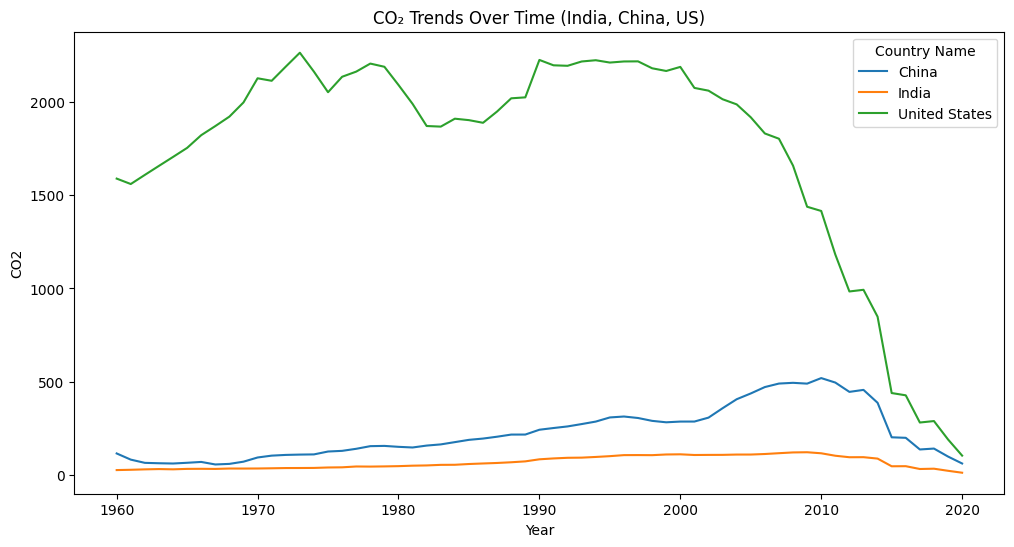

In [11]:
plt.figure(figsize=(10,6))
sns.histplot(cleaned_datasets["CO2"]["CO2"], bins=50, kde=True)
plt.title("Distribution of CO₂ emissions (tons per capita)")
plt.savefig("CO2_hist.png")
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(x=cleaned_datasets["CO2"]["CO2"])
plt.title("CO₂ Spread and Outliers")
plt.savefig("CO2_box.png")
plt.show()

df_sample = cleaned_datasets["CO2"][cleaned_datasets["CO2"]["Country Name"].isin(sample_countries)]

plt.figure(figsize=(12,6))
sns.lineplot(data=df_sample, x="Year", y="CO2", hue="Country Name")
plt.title("CO₂ Trends Over Time (India, China, US)")
plt.savefig("CO2_line.png")
plt.show()

# 7.) Inferences

*  The importance of preprocessing & visualization for better clarity and understanding.
>
*  What we understood from this Banana Problem in terms of its usage and implementation are as follows :-
> *   Data Scraping / Web Scraping
> *   BeautifulScoup
> *   Handling missing values, dtypes, etc.
> *   Visualizing the graphs/plots using seaborn & matplotlib



In [12]:
inferences = """
1. GDP (current US$):
   - Distribution is highly skewed: most countries have small GDP, while USA and China dominate.
   - Boxplot shows many outliers at the higher end.
   - Line plot: China rises sharply after the 1990s, India grows steadily, USA remains highest.

2. Population, total:
   - Most countries have small populations; India and China are extreme outliers.
   - Boxplot confirms this skewed distribution.
   - Line plot: India and China grow steeply; USA grows more slowly.

3. Literacy rate (adult %):
   - Most countries cluster above 80% literacy.
   - Some outliers remain below 60%.
   - Line plot: global literacy improves steadily, especially in developing regions.

4. CO₂ emissions (metric tons per capita):
   - Most countries emit less than 5 tons per person; developed nations much higher.
   - Boxplot shows skew with very high outliers (USA, oil-rich countries).
   - Line plot: USA stays high, China rises fast after 2000, India remains low.
"""
print(inferences)



1. GDP (current US$):
   - Distribution is highly skewed: most countries have small GDP, while USA and China dominate.
   - Boxplot shows many outliers at the higher end.
   - Line plot: China rises sharply after the 1990s, India grows steadily, USA remains highest.

2. Population, total:
   - Most countries have small populations; India and China are extreme outliers.
   - Boxplot confirms this skewed distribution.
   - Line plot: India and China grow steeply; USA grows more slowly.

3. Literacy rate (adult %):
   - Most countries cluster above 80% literacy.
   - Some outliers remain below 60%.
   - Line plot: global literacy improves steadily, especially in developing regions.

4. CO₂ emissions (metric tons per capita):
   - Most countries emit less than 5 tons per person; developed nations much higher.
   - Boxplot shows skew with very high outliers (USA, oil-rich countries).
   - Line plot: USA stays high, China rises fast after 2000, India remains low.

